In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

In [2]:
import tensorflow as tf

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
df = pd.read_parquet("without_CID.parquet")


print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (731512, 26)


,PPI_LEN,PPI_ROUNDTRIPS,log_ppi_duration,log_mean_ipt,log_std_ipt,mean_packet_size,std_packet_size,direction_change_ratio,forward_packet_ratio,src_size_entropy,...,log_byte_rate,avg_packet_size,log_byte_ratio,log_packet_ratio,quic_version_id,QUIC_TOKEN_LENGTH,log_zero_rtt,zero_rtt_present,log_multiplexed,multiplexed
0,30,3,0.087095,1.394593,1.844657,305.066667,448.216609,0.206897,0.533333,0.749714,...,8.935008,362.574766,0.307033,0.603802,1,70,1.791759,1,0.0,0
1,30,8,0.786638,3.710315,5.200603,285.400000,426.120609,0.517241,0.500000,0.726207,...,6.111156,250.441860,1.381015,0.670158,1,71,1.098612,1,0.0,0
2,30,6,0.101654,1.518784,2.285496,551.833333,553.884530,0.379310,0.533333,0.611467,...,9.609840,566.285714,2.195140,0.847298,1,70,0.693147,1,0.0,0
3,25,5,0.226338,2.412336,3.506581,437.080000,515.110700,0.416667,0.480000,0.819716,...,10.732316,465.080000,0.590181,0.653926,1,71,0.693147,1,0.0,0
4,19,4,0.076035,1.640528,1.912475,485.894737,551.395635,0.444444,0.473684,0.732387,...,11.770143,533.894737,0.742657,0.641854,1,70,1.609438,1,0.0,0


In [4]:
X_train, X_test = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (585209, 26)
Testing Shape  : (146303, 26)


In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [6]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=df.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=df.columns,
    index=X_test.index
)

In [7]:
from tensorflow.keras.layers import (
    Input, Dense, Dropout
)
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping


input_dim = X_train_scaled.shape[1]

input_layer = Input(shape=(input_dim,))

# Encoder
x = Dense(
    64,
    activation='relu',
    kernel_regularizer=l2(1e-5)
)(input_layer)
x = Dropout(0.1)(x)

x = Dense(
    32,
    activation='relu',
    kernel_regularizer=l2(1e-5)
)(x)
x = Dropout(0.1)(x)

x = Dense(
    16,
    activation='relu',
    kernel_regularizer=l2(1e-5)
)(x)

# Latent Space
latent = Dense(
    10,
    activation='linear',
    name='latent'
)(x)

# Decoder
x = Dense(16, activation='relu')(latent)
x = Dense(32, activation='relu')(x)
x = Dense(64, activation='relu')(x)

output_layer = Dense(
    input_dim,
    activation='linear'
)(x)

autoencoder = Model(input_layer, output_layer)
encoder_model = Model(input_layer, latent)

autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

history = autoencoder.fit(
    X_train_scaled,
    X_train_scaled,
    epochs=200,
    batch_size=2048,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
229/229 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - loss: 0.4484 - val_loss: 0.2153
Epoch 2/200
229/229 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 0.2104 - val_loss: 0.1348
Epoch 3/200
229/229 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 0.1628 - val_loss: 0.1082
Epoch 4/200
229/229 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1434 - val_loss: 0.0956
Epoch 5/200
229/229 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1326 - val_loss: 0.0876
Epoch 6/200
229/229 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - loss: 0.1249 - val_loss: 0.0828
Epoch 7/200
229/229 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.1185 - val_loss: 0.0795
Epoch 8/200
229/229 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.1133 - val_loss: 0.0764
Epoch 9/200
229/229 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss: 0.1096 - val_loss: 0.0738
Epoch 10/200
229/229 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1061 - val_loss: 0.0724
Epoch 11/200
229/229 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 0.1034 - val_loss: 0.0699
Epoch 12/200
229/229 ━━━━━━━

In [8]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 26)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           1,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ latent (Dense)                       │ (None, 10)                  │             170 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 16)                  │             176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 26)                  │           1,690 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 27,086 (105.81 KB)

 Trainable params: 9,028 (35.27 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 18,058 (70.54 KB)

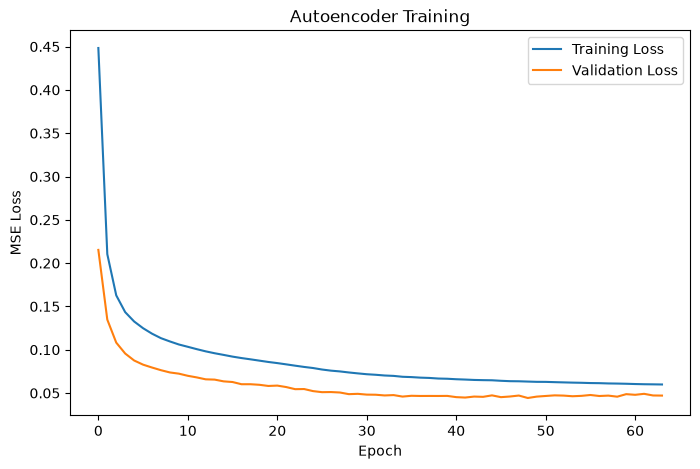

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training")

plt.legend()

plt.show()

In [10]:
latent_train = encoder_model.predict(X_train_scaled)

latent_test = encoder_model.predict(X_test_scaled)

print("Train:", latent_train.shape)
print("Test :", latent_test.shape)

18288/18288 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step
4572/4572 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step
Train: (585209, 10)
Test : (146303, 10)


In [11]:
latent_columns = [f"latent_{i+1}" for i in range(10)]

latent_train = pd.DataFrame(
    latent_train,
    columns=latent_columns
)

latent_test = pd.DataFrame(
    latent_test,
    columns=latent_columns
)

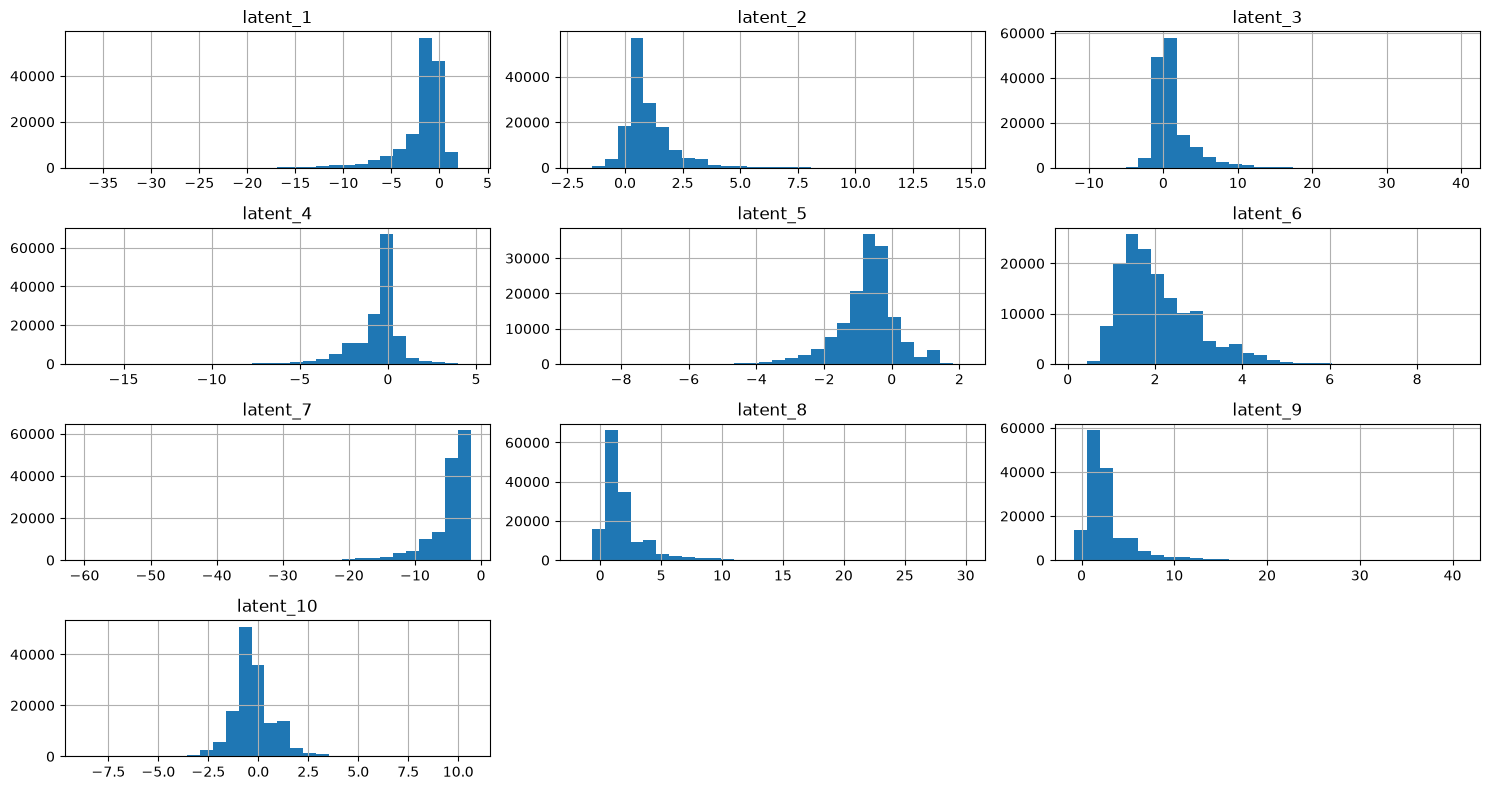

In [12]:
latent_test.hist(
    figsize=(15,8),
    bins=30
)

plt.tight_layout()
plt.show()

In [13]:
iso_forest = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

In [14]:
iso_forest.fit(latent_train)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [15]:
predictions = iso_forest.predict(latent_test)
anomaly_scores = -iso_forest.score_samples(latent_test)

In [16]:
results = latent_test.copy()

results["anomaly_score"] = anomaly_scores

results["prediction"] = predictions

results.head()

,latent_1,latent_2,latent_3,latent_4,latent_5,latent_6,latent_7,latent_8,latent_9,latent_10,anomaly_score,prediction
0,-1.041746,0.185573,-0.063305,0.208304,-1.226911,1.630890,-2.958680,1.038927,1.064254,-0.733769,0.375255,1
1,-0.669048,0.402516,0.607635,0.366673,-0.812511,1.439983,-2.885211,1.195248,0.861646,-0.260016,0.371754,1
2,-4.321074,1.980174,5.507686,-2.333235,-1.608994,2.822259,-8.797341,4.167587,5.215726,1.240550,0.453730,1
3,0.176923,0.642454,1.509932,-0.264549,0.027000,2.056717,-2.384118,0.709968,0.503307,0.510279,0.422273,1
4,-3.232942,1.961766,-3.308519,-2.707248,0.108264,2.497324,-4.345364,1.632625,3.767304,-3.268031,0.547704,-1


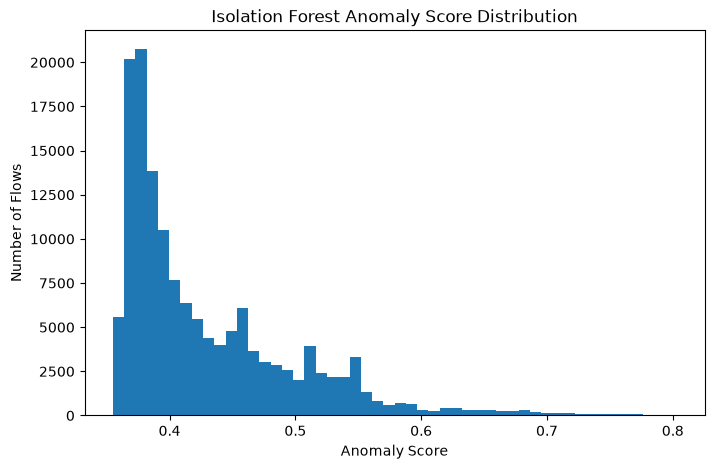

In [17]:
plt.figure(figsize=(8,5))

plt.hist(anomaly_scores,
         bins=50)

plt.xlabel("Anomaly Score")

plt.ylabel("Number of Flows")

plt.title("Isolation Forest Anomaly Score Distribution")

plt.show()

In [18]:
score_series = pd.Series(anomaly_scores)

print(score_series.describe())

print("\nSkewness:", score_series.skew())

count    146303.000000
mean          0.430032
std           0.070927
min           0.354896
25%           0.377063
50%           0.401968
75%           0.462623
max           0.802878
dtype: float64

Skewness: 1.6064268431411497


In [19]:
print("Normal flows :", np.sum(predictions == 1))
print("Anomalous flows :", np.sum(predictions == -1))

Normal flows : 122155
Anomalous flows : 24148


In [20]:
results = df.loc[X_test.index].copy()
results["anomaly_score"] = anomaly_scores

In [21]:
threshold = np.percentile(anomaly_scores, 95)

normal = results[results["anomaly_score"] < threshold]
anomalous = results[results["anomaly_score"] >= threshold]

print("Normal flows:", len(normal))
print("Anomalous flows:", len(anomalous))

Normal flows: 138987
Anomalous flows: 7316


In [22]:
from sklearn.decomposition import PCA

In [23]:
pca = PCA(n_components=2)

latent_pca = pca.fit_transform(latent_test)

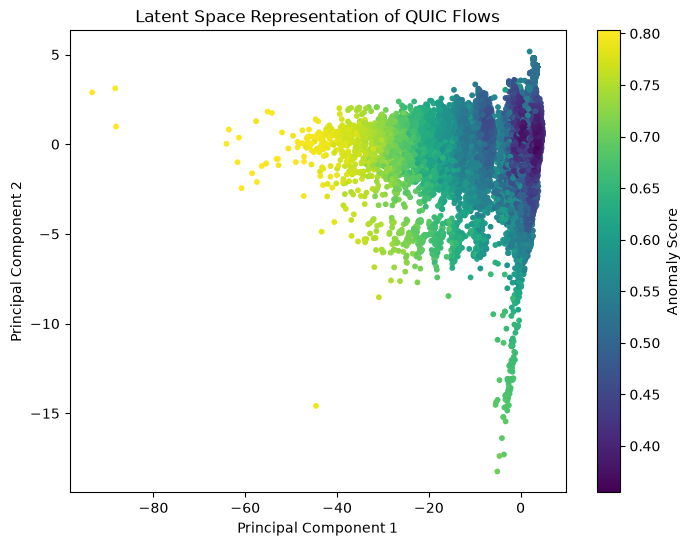

In [24]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    latent_pca[:,0],
    latent_pca[:,1],
    c=anomaly_scores,
    cmap="viridis",
    s=10
)

plt.colorbar(scatter, label="Anomaly Score")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("Latent Space Representation of QUIC Flows")

plt.show()

In [25]:
seeds = [42, 100, 200, 500]


score_df = pd.DataFrame(index=latent_test.index)

for seed in seeds:

    iso = IsolationForest(
        n_estimators=200,
        contamination="auto",
        random_state=seed
    )

    iso.fit(latent_train)

    score_df[f"Seed_{seed}"] = -iso.score_samples(latent_test)

score_df.head()

,Seed_42,Seed_100,Seed_200,Seed_500
0,0.375255,0.376162,0.369558,0.376605
1,0.371754,0.372217,0.365773,0.373339
2,0.453730,0.451031,0.458176,0.453221
3,0.422273,0.411885,0.415097,0.413928
4,0.547704,0.553532,0.560920,0.547275


In [26]:
correlation = score_df.corr()

correlation

,Seed_42,Seed_100,Seed_200,Seed_500
Seed_42,1.000000,0.992401,0.992388,0.992352
Seed_100,0.992401,1.000000,0.992533,0.994243
Seed_200,0.992388,0.992533,1.000000,0.993082
Seed_500,0.992352,0.994243,0.993082,1.000000


In [27]:
top_anomalies = {}

for column in score_df.columns:

    threshold = score_df[column].quantile(0.95)

    top_anomalies[column] = set(
        score_df.index[
            score_df[column] >= threshold
        ]
    )

In [28]:
from itertools import combinations

overlap_results = []

for seed_1, seed_2 in combinations(score_df.columns, 2):

    common = len(
        top_anomalies[seed_1].intersection(
            top_anomalies[seed_2]
        )
    )

    total = len(top_anomalies[seed_1])

    overlap = (common / total) * 100

    overlap_results.append([
        seed_1,
        seed_2,
        common,
        round(overlap,2)
    ])

overlap_df = pd.DataFrame(
    overlap_results,
    columns=[
        "Seed 1",
        "Seed 2",
        "Common Anomalies",
        "Overlap (%)"
    ]
)

overlap_df

,Seed 1,Seed 2,Common Anomalies,Overlap (%)
0,Seed_42,Seed_100,6706,91.66
1,Seed_42,Seed_200,6734,92.04
2,Seed_42,Seed_500,6869,93.89
3,Seed_100,Seed_200,6881,94.05
4,Seed_100,Seed_500,6892,94.20
5,Seed_200,Seed_500,6838,93.47


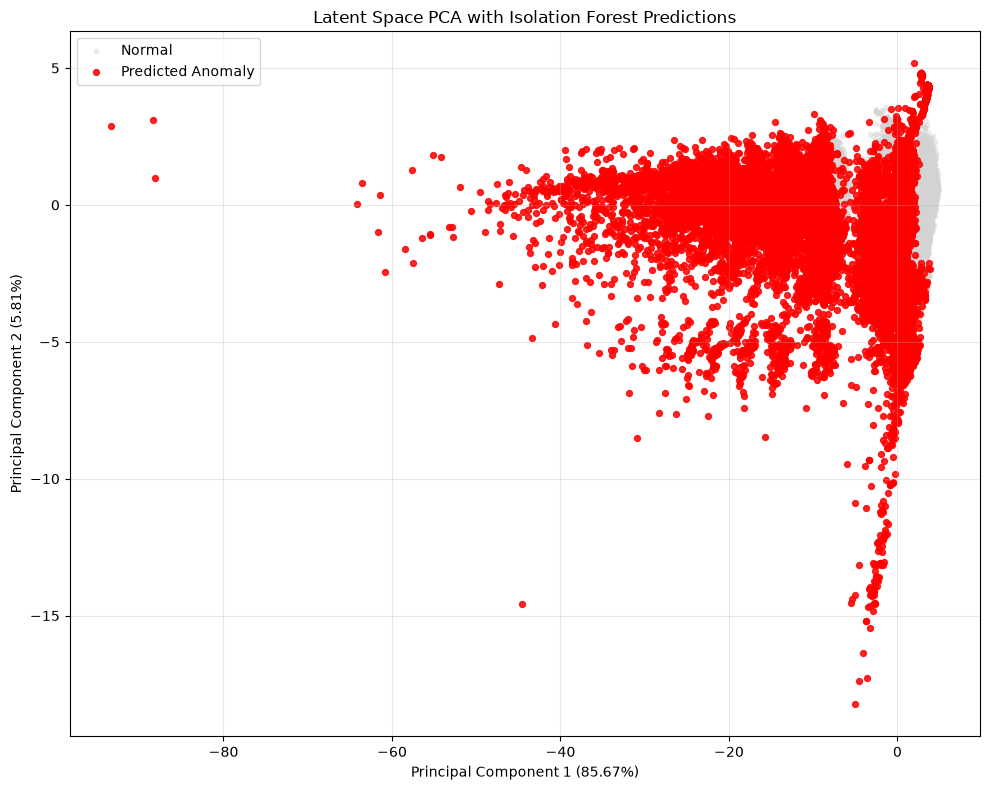

In [29]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Reduce latent space to 2D
pca = PCA(n_components=2, random_state=42)
latent_pca = pca.fit_transform(latent_test)

# Boolean masks
normal_mask = predictions == 1
anomaly_mask = predictions == -1

plt.figure(figsize=(10,8))

# Normal flows
plt.scatter(
    latent_pca[normal_mask,0],
    latent_pca[normal_mask,1],
    s=10,
    c='lightgrey',
    alpha=0.35,
    label='Normal'
)

# Anomalies
plt.scatter(
    latent_pca[anomaly_mask,0],
    latent_pca[anomaly_mask,1],
    s=18,
    c='red',
    alpha=0.85,
    label='Predicted Anomaly'
)

plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
plt.title("Latent Space PCA with Isolation Forest Predictions")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(latent_test, predictions)

print(f"Silhouette Score: {silhouette:.4f}")

Silhouette Score: 0.5076


In [31]:
from sklearn.metrics import davies_bouldin_score

db_index = davies_bouldin_score(latent_test, predictions)

print(f"Davies-Bouldin Index: {db_index:.4f}")

Davies-Bouldin Index: 1.4681


In [32]:
results_df = pd.DataFrame(
    latent_test,
    columns=[f"latent_{i+1}" for i in range(latent_test.shape[1])]
)

results_df["flow_index"] = X_test.index
results_df["anomaly_score"] = anomaly_scores
results_df["prediction"] = predictions

# Put flow_index first
results_df = results_df[
    ["flow_index"] +
    [c for c in results_df.columns if c != "flow_index"]
]

results_df.head()

,flow_index,latent_1,latent_2,latent_3,latent_4,latent_5,latent_6,latent_7,latent_8,latent_9,latent_10,anomaly_score,prediction
0,491814,-1.041746,0.185573,-0.063305,0.208304,-1.226911,1.630890,-2.958680,1.038927,1.064254,-0.733769,0.375255,1
1,547209,-0.669048,0.402516,0.607635,0.366673,-0.812511,1.439983,-2.885211,1.195248,0.861646,-0.260016,0.371754,1
2,313159,-4.321074,1.980174,5.507686,-2.333235,-1.608994,2.822259,-8.797341,4.167587,5.215726,1.240550,0.453730,1
3,417373,0.176923,0.642454,1.509932,-0.264549,0.027000,2.056717,-2.384118,0.709968,0.503307,0.510279,0.422273,1
4,451613,-3.232942,1.961766,-3.308519,-2.707248,0.108264,2.497324,-4.345364,1.632625,3.767304,-3.268031,0.547704,-1


In [35]:
results_df.to_parquet(
    "without_CID_results.parquet",
    index=False
)

In [36]:
X_test.to_parquet("without_CID_test_features.parquet")